In [ ]:
# Run in conda ibiz environment
import torch
import pandas as pd
import xarray as xr
import os

import importlib
import preprocess_radargrams_configs
importlib.reload(preprocess_radargrams_configs)

<module 'preprocess_radargrams_configs' from '/Users/kim.bente/Code/RadarCLIP/preprocess_radargrams_configs.py'>

In [12]:
# location of tar file
# NOTE: Start with 2016 data, as it is more recent and has better coverage
from preprocess_radargrams_configs import PATH_2016_AN_UTIG_ER2HI1B, PATH_2016_AN_UTIG_ER2HI2, CODE_1B, CODE_2
PATH_2016_AN_UTIG_ER2HI1B_folder = os.path.join(PATH_2016_AN_UTIG_ER2HI1B, "2016_AN_UTIG.ER2HI1B")

# Extract the list of .nc files in the folder
list_of_nc_files_2016_UTIG = [
    f for f in os.listdir(PATH_2016_AN_UTIG_ER2HI1B_folder) 
    if f.endswith(".nc")
    ]

list_of_nc_files_2016_UTIG_full_paths = [
    os.path.join(PATH_2016_AN_UTIG_ER2HI1B_folder, f)
    for f in os.listdir(PATH_2016_AN_UTIG_ER2HI1B_folder)
    if f.endswith(".nc")
]

# Proprocessing pipeline for radar data

## Steps
- Start from one image first
- Extract location of bed 
- crop IBIZ 
- Have a fixed scale
- Combine with bed picks

# Acronyms
- ER2HI1B - EAGLE Radar (?!) - HiCARS - Level 1B data
- ER2HI2 - EAGLE Radar (?!) - HiCARS - Level 2 data

In [5]:
path_to_a_radargram = list_of_nc_files_2016_UTIG_full_paths[0]

In [9]:
radargram_ds = xr.open_dataset(path_to_a_radargram)
print("Granule ID:", radargram_ds.granule_id)
radargram_ds

Granule ID: ER2HI1B_2017024_TOT1_JKB2r_X19a_000


<xarray.Dataset> Size: 103MB
Dimensions:              (fasttime_dim: 3200, time: 4000)
Coordinates:
  * time                 (time) datetime64[ns] 32kB 2017-01-24T07:55:32.56640...
Dimensions without coordinates: fasttime_dim
Data variables:
    fasttime             (fasttime_dim) float32 13kB ...
    lat                  (time) float32 16kB ...
    lon                  (time) float32 16kB ...
    altitude             (time) float32 16kB ...
    pitch                (time) float32 16kB ...
    roll                 (time) float32 16kB ...
    heading              (time) float32 16kB ...
    amplitude_low_gain   (time, fasttime_dim) float32 51MB ...
    amplitude_high_gain  (time, fasttime_dim) float32 51MB ...
Attributes: (12/27)
    featureType:          timeSeries
    location:             C-GJKB
    source:               airborne ice penetrating radar
    data_version:         JUN292018
    netcdf_version:       4.1.2 of Apr 12 2011 15:15:12 $
    positioning:          transect based Ashtech CA GG24 reciever (no orrieta...
    ...                   ...
    rfparams:             RF PARAMETERS\nCenter Frequency: 60 MHz\nCenter Wav...
    digital:              DIGITAL PARAMETERS\nRecord duration: 64 microsecond...
    TX-record_offset:     Transmit delay from record start: 2.550 microseconds\n
    antenna:              ANTENNA PARAMETERS:\nPlatform: C-GJKB DC-3T aircraf...
    processing:           PROCESSING PARAMETERS\nMode name: pik1\nGoal: emula...
    references:           Peters, M.E., D.D. Blankenship, S.P. Carter, D.A. Y...

In [7]:
# We have lat lon all across, tightly discretised
radargram_ds.lon.values

array([113.8726  , 113.87305 , 113.8735  , ..., 115.64972 , 115.65016 ,
       115.650604], shape=(4000,), dtype=float32)

Matplotlib is building the font cache; this may take a moment.


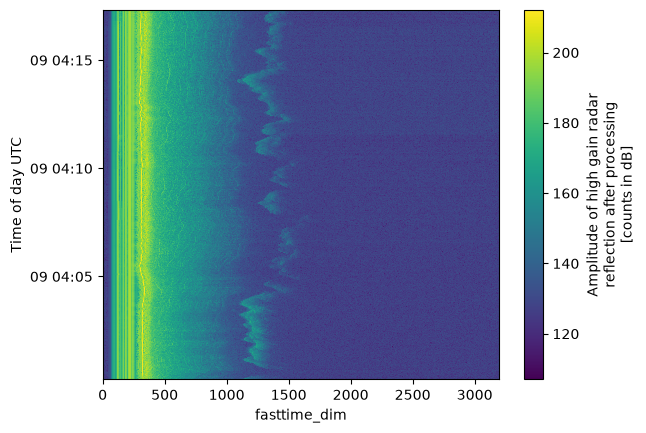

In [ ]:
radargram_ds
# high gain more relevant for bed detection, low gain more relevant for surface detection
radargram_ds["amplitude_high_gain"].plot()

# Find matching bed pick

Granule ID: ER2HI1B_2017024_TOT1_JKB2r_X19a_000


In [ ]:
PATH_2016_AN_UTIG_ER2HI2

radargram_grandule_id_L2 = radargram_ds.granule_id[:5] + "2" + radargram_ds.granule_id[7:]
radargram_grandule_id_L2_cropped = radargram_grandule_id_L2[:-3]

PATH_L1B = PATH_2016_AN_UTIG_ER2HI2 + "/" + radargram_grandule_id_L2_cropped + "icethk.txt"
print(PATH_L1B)
# print("/Users/kim.bente/Documents/ANT_QGIS/AADC-DATA/AAS_4346_EAGLE_ICECAP_LEVEL2_AEROGEOPHYSICS/EAGLE-2015-2016-Level2/Level2/2016_AN_UTIG.ER2HI2/ER2HI2_2017024_TOT1_JKB2r_X19a_icethk.txt")

/Users/kim.bente/Documents/ANT_QGIS/AADC-DATA/AAS_4346_EAGLE_ICECAP_LEVEL2_AEROGEOPHYSICS/EAGLE-2015-2016-Level2/Level2/2016_AN_UTIG.ER2HI2/ER2HI2_2017024_TOT1_JKB2r_X19a_icethk.txt
/Users/kim.bente/Documents/ANT_QGIS/AADC-DATA/AAS_4346_EAGLE_ICECAP_LEVEL2_AEROGEOPHYSICS/EAGLE-2015-2016-Level2/Level2/2016_AN_UTIG.ER2HI2/ER2HI2_2017024_TOT1_JKB2r_X19a_icethk.txt


In [24]:
# import L2 text file
df = pd.read_csv(
    PATH_L1B,
    sep = r"\s+",       # whitespace-delimited (handles single or multiple spaces)
    comment = "#",       # skips any line starting with '#'
    header = None        # set to None for now; add column names once you've seen the header
)

df.head()

,0,1,2,3,4,5,6,7,8,9,10,11
0,2017,24,28532.5655,113.872598,-67.610099,1249.84,1029.35,-768.33,481.51,-58.69,-33.18,-9999.0
1,2017,24,28532.8212,113.873047,-67.610024,1244.53,999.59,-733.12,511.41,-57.32,-34.69,-9999.0
2,2017,24,28533.0771,113.873496,-67.609949,1204.04,1002.24,-695.16,508.88,-59.32,-31.16,-9999.0
3,2017,24,28533.3339,113.873947,-67.609874,1205.95,997.76,-692.50,513.45,-55.82,-34.47,-9999.0
4,2017,24,28533.5894,113.874396,-67.609800,1192.47,1001.67,-682.83,509.64,-57.73,-31.19,-9999.0


# Questions:
How close are the picks? 
Can we match them with the radar data purely based in lon lat?
use reflectivity and other for correlation analysis (after) or also for processing?
Aircraft height is not in the L2 dataset.

Off-set to fix aircraft altitude...